# COMP4318/5318 Assignment 2: Image Classification

#### Group number: 100
##### SID1: 530839244
##### SID2: 540958494
##### SID3: 550120560
##### SID4: 550053316

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment. 

In [1]:
# --- Numerical / data handling ---------------------------------------------
import numpy as np
import pandas as pd

# --- Plotting ---------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", context="notebook")

# --- Classical ML -----------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Deep learning ----------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers

# --- Utilities --------------------------------------------------------------
import time, os, json, itertools
from collections import Counter

# --- Reproducibility --------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# --- Hardware sanity check --------------------------------------------------
print("TensorFlow version :", tf.__version__)
print("Visible GPUs       :", tf.config.list_physical_devices("GPU"))


TensorFlow version : 2.21.0
Visible GPUs       : []


## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

### 1.1 Loading the dataset
We load the four NumPy arrays distributed on Canvas. The training and test splits are pre-defined; we will additionally carve a validation set out of the training split below for hyper-parameter selection.

In [2]:
# Load the dataset training and test sets as numpy arrays
X_train = np.load("Data/X_train.npy")
y_train = np.load("Data/y_train.npy")
X_test  = np.load("Data/X_test.npy")
y_test  = np.load("Data/y_test.npy")

print(f"X_train shape: {X_train.shape},  dtype: {X_train.dtype}")
print(f"y_train shape: {y_train.shape},  dtype: {y_train.dtype}")
print(f"X_test  shape: {X_test.shape},  dtype: {X_test.dtype}")
print(f"y_test  shape: {y_test.shape},  dtype: {y_test.dtype}")


X_train shape: (32000, 28, 28, 3),  dtype: uint8
y_train shape: (32000,),  dtype: uint8
X_test  shape: (8000, 28, 28, 3),  dtype: uint8
y_test  shape: (8000,),  dtype: uint8


### 1.2 Class definitions
PathMNIST is a 9-class colorectal histology dataset taken from the MedMNIST v2 benchmark. The class index → tissue type mapping below follows the official MedMNIST v2 release.

In [3]:
# PathMNIST class index -> tissue name (per MedMNIST v2)
class_names = {
    0: "Adipose",
    1: "Background",
    2: "Debris",
    3: "Lymphocytes",
    4: "Mucus",
    5: "Smooth Muscle",
    6: "Normal Colon Mucosa",
    7: "Cancer-associated Stroma",
    8: "Colorectal Adenocarcinoma Epithelium",
}
NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")
for k, v in class_names.items():
    print(f"  Class {k}: {v}")


Number of classes: 9
  Class 0: Adipose
  Class 1: Background
  Class 2: Debris
  Class 3: Lymphocytes
  Class 4: Mucus
  Class 5: Smooth Muscle
  Class 6: Normal Colon Mucosa
  Class 7: Cancer-associated Stroma
  Class 8: Colorectal Adenocarcinoma Epithelium


### 1.3 Sample sizes and class balance
We print the per-split sample counts using `len(...)` so the text never drifts out of sync with the actual arrays. PathMNIST is mildly imbalanced; the bar plot below confirms whether class re-weighting may be needed.

Training samples : 32,000
Test samples     : 8,000
Image dimensions : 28x28x3 (HxWxC)
Pixel dtype      : uint8 (range 0..255)


,class,count,proportion
0,Adipose,3490,10.91%
1,Background,3431,10.72%
2,Debris,3505,10.95%
3,Lymphocytes,3656,11.43%
4,Mucus,2950,9.22%
5,Smooth Muscle,4290,13.41%
6,Normal Colon Mucosa,2728,8.53%
7,Cancer-associated Stroma,3253,10.17%
8,Colorectal Adenocarcinoma Epithelium,4697,14.68%


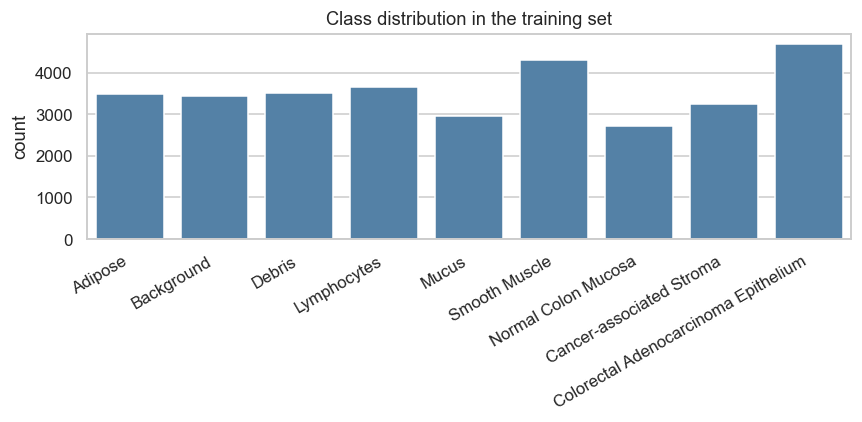

Imbalance ratio (max/min): 1.72


In [4]:
print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Image dimensions : {X_train.shape[1]}x{X_train.shape[2]}x{X_train.shape[3]} (HxWxC)")
print(f"Pixel dtype      : {X_train.dtype} (range {X_train.min()}..{X_train.max()})")

unique, counts = np.unique(y_train, return_counts=True)
class_balance = pd.DataFrame({
    "class": [class_names[u] for u in unique],
    "count": counts,
    "proportion": counts / counts.sum(),
})
display(class_balance.style.format({"proportion": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=class_balance, x="class", y="count", ax=ax,
            color="steelblue")
ax.set_title("Class distribution in the training set")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")


### 1.4 Sample images per class
Three random images per class are shown to give an intuition for what the classifier has to discriminate. Many classes share a pinkish H&E stain colour and primarily differ by texture — a feature CNNs are particularly suited to capture.

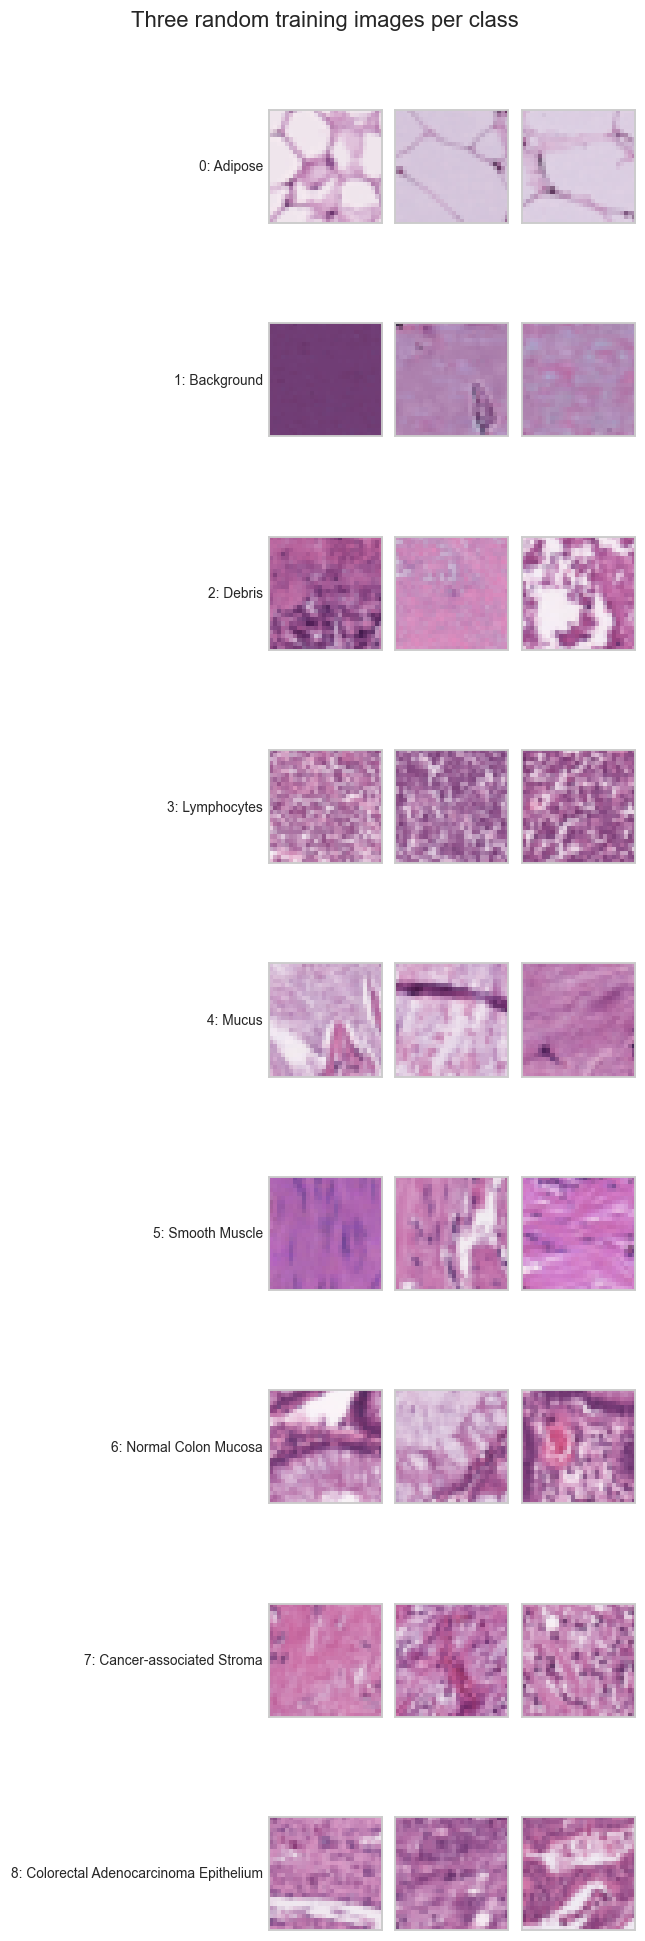

In [5]:
rng = np.random.default_rng(RANDOM_SEED)
classes = np.unique(y_train)
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(6, 2 * NUM_CLASSES))
for i, cls in enumerate(classes):
    idxs = np.where(y_train == cls)[0]
    selected = rng.choice(idxs, 3, replace=False)
    for j, k in enumerate(selected):
        ax = axes[i, j]
        ax.imshow(X_train[k])
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f"{cls}: {class_names[cls]}", rotation=0,
                          ha="right", va="center", fontsize=9)
fig.suptitle("Three random training images per class", y=1.0)
plt.tight_layout()
plt.show()


### 1.5 Pixel intensity analysis
We inspect the per-channel pixel distribution to decide what kind of scaling is appropriate. The values lie in the standard 0–255 uint8 range, motivating a simple division by 255 to bring them into the [0, 1] range used by neural network optimisers.

Red    mean=188.65  std= 31.91
Green  mean=135.93  std= 45.60
Blue   mean=180.05  std= 32.18


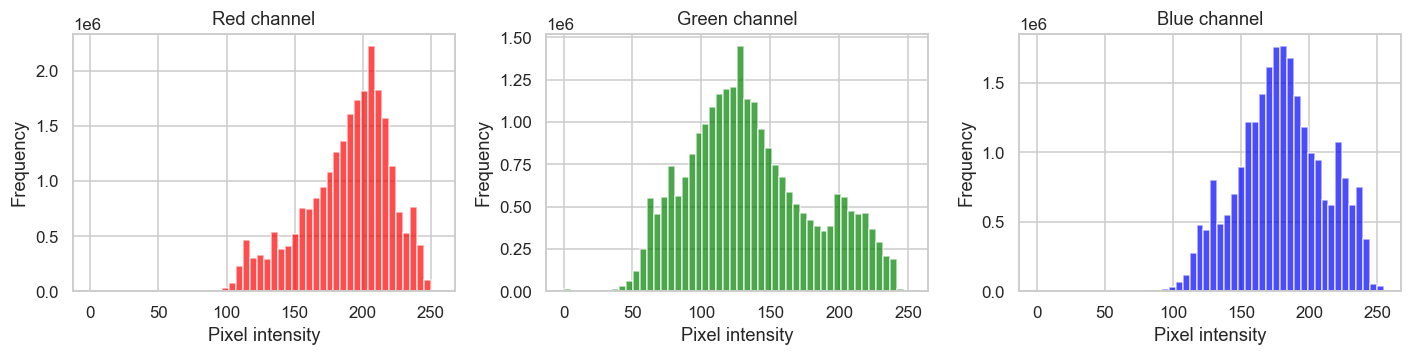

In [6]:
channel_names = ["Red", "Green", "Blue"]
colours = ["red", "green", "blue"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for c in range(3):
    data = X_train[..., c].ravel()
    axes[c].hist(data, bins=50, color=colours[c], alpha=0.7)
    axes[c].set_title(f"{channel_names[c]} channel")
    axes[c].set_xlabel("Pixel intensity")
    axes[c].set_ylabel("Frequency")
    print(f"{channel_names[c]:<5}  mean={data.mean():6.2f}  std={data.std():6.2f}")
plt.tight_layout()
plt.show()


### 1.6 Pre-processing
Two pre-processing pipelines are produced because the three classifiers consume data in different shapes:

* **Neural network branch (MLP / CNN)** — pixels are scaled to `[0, 1]` by dividing by 255. Keeping pixel intensities small and bounded improves gradient stability and avoids any single colour channel dominating because of its scale.
* **Classical-ML branch (SVM)** — each image is additionally flattened from `(28, 28, 3)` into a 2 352-dimensional feature vector, which is the input shape expected by `sklearn.svm.SVC`. We will further apply PCA inside the SVM pipeline (see §2) to keep the kernel evaluation tractable.

Standardisation (subtracting the per-feature mean and dividing by the standard deviation) was considered for the SVM branch and is applied as part of the final pipeline; we keep the un-standardised flattened tensors here so each model can scale them as required.

In [7]:
# Neural-network branch: scale pixels to [0, 1]
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm  = X_test.astype("float32")  / 255.0

# Classical-ML branch: flatten to (N, 2352)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"Normalised pixel range : [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]")
print(f"NN-branch shape        : {X_train_norm.shape}")
print(f"Classical-branch shape : {X_train_flat.shape}")


Normalised pixel range : [0.000, 1.000]
NN-branch shape        : (32000, 28, 28, 3)
Classical-branch shape : (32000, 2352)


### 1.7 Train / validation split
The provided test set must only be used to evaluate the final selected models. For hyper-parameter tuning we therefore split the training set into a smaller training subset and a held-out validation subset. We use a stratified split so the class proportions are preserved on both sides.

In [8]:
VAL_FRACTION = 0.2

(X_tr_norm, X_val_norm,
 X_tr_flat, X_val_flat,
 y_tr,      y_val) = train_test_split(
    X_train_norm, X_train_flat, y_train,
    test_size=VAL_FRACTION,
    stratify=y_train,
    random_state=RANDOM_SEED,
)

print(f"Train subset (NN)        : {X_tr_norm.shape}")
print(f"Validation subset (NN)   : {X_val_norm.shape}")
print(f"Train subset (classical) : {X_tr_flat.shape}")
print(f"Validation (classical)   : {X_val_flat.shape}")

tr_props  = pd.Series(y_tr).value_counts(normalize=True).sort_index()
val_props = pd.Series(y_val).value_counts(normalize=True).sort_index()
props = pd.DataFrame({"train": tr_props, "val": val_props}).round(3)
props.index = props.index.map(class_names)
display(props)


Train subset (NN)        : (25600, 28, 28, 3)
Validation subset (NN)   : (6400, 28, 28, 3)
Train subset (classical) : (25600, 2352)
Validation (classical)   : (6400, 2352)


,train,val
Adipose,0.109,0.109
Background,0.107,0.107
Debris,0.110,0.110
Lymphocytes,0.114,0.114
Mucus,0.092,0.092
Smooth Muscle,0.134,0.134
Normal Colon Mucosa,0.085,0.085
Cancer-associated Stroma,0.102,0.102
Colorectal Adenocarcinoma Epithelium,0.147,0.147


### Examples of preprocessed data
Below we show the same training image after each of the two preprocessing pipelines. The neural-network input is a 3-channel 28×28 float tensor in `[0, 1]` and is visually identical to the original. The classical-ML input is the same tensor flattened to a 2 352-dimensional vector, visualised here as a stacked 1-D strip.

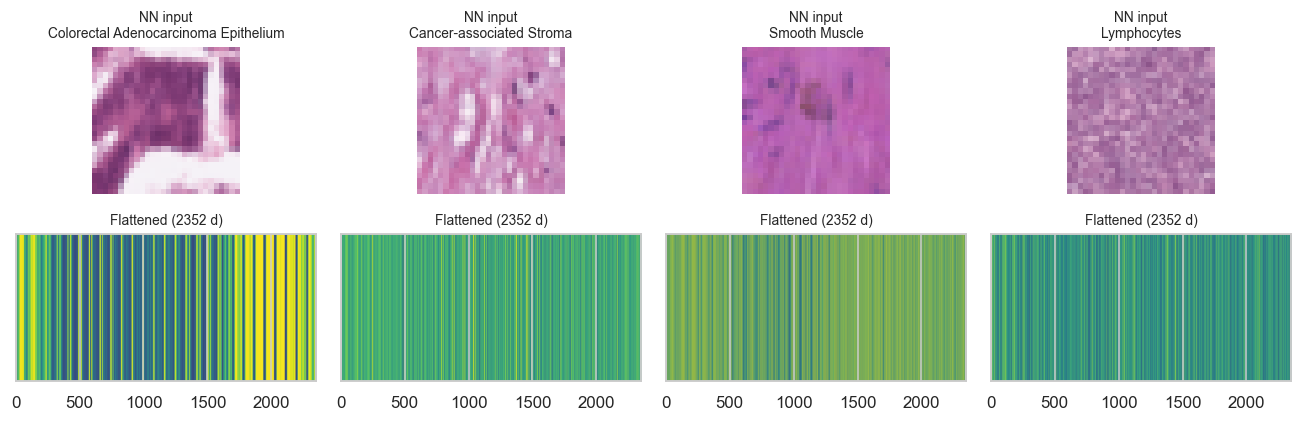

NN-input min/max : 0.000 / 1.000
Flat-input shape : (25600, 2352) (each row is one image)


In [9]:
sample_idx = rng.choice(len(X_tr_norm), 4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(12, 4))
for j, k in enumerate(sample_idx):
    axes[0, j].imshow(X_tr_norm[k])
    axes[0, j].set_title(f"NN input\n{class_names[int(y_tr[k])]}", fontsize=9)
    axes[0, j].axis("off")

    flat = X_tr_flat[k].reshape(1, -1)
    axes[1, j].imshow(flat, aspect="auto", cmap="viridis")
    axes[1, j].set_title("Flattened (2352 d)", fontsize=9)
    axes[1, j].set_yticks([])
plt.tight_layout()
plt.show()

print(f"NN-input min/max : {X_tr_norm.min():.3f} / {X_tr_norm.max():.3f}")
print(f"Flat-input shape : {X_tr_flat.shape} (each row is one image)")


## 2. Algorithm design and setup

In [10]:
# A2: shared model factories used by §2, §3 and §4.
# Defining the architectures here keeps §3 / §4 cells short and consistent.

from pathlib import Path
OUTPUTS_DIR = Path("Outputs")
OUTPUTS_DIR.mkdir(exist_ok=True)


def make_svm(C=1.0, gamma="scale", n_components=50, random_state=RANDOM_SEED):
    """Standardise -> PCA -> RBF SVC."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_components, random_state=random_state)),
        ("svc",    SVC(C=C, gamma=gamma, kernel="rbf",
                       random_state=random_state, cache_size=500)),
    ])


def make_mlp(units=128, dropout=0.3, learning_rate=1e-3, num_classes=NUM_CLASSES):
    """Two-hidden-layer feed-forward network."""
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 3)),
        layers.Flatten(),
        layers.Dense(units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(units // 2, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def make_cnn(filters=32, dropout=0.3, learning_rate=1e-3,
             kernel_size=3, num_classes=NUM_CLASSES):
    """A small two-block convolutional network."""
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 3)),
        layers.Conv2D(filters, kernel_size, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters * 2, kernel_size, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


print("Model factories defined: make_svm, make_mlp, make_cnn")


Model factories defined: make_svm, make_mlp, make_cnn


### Algorithm of choice from first six weeks of course
We choose the **Support Vector Machine (SVM)** with an RBF kernel as our classical algorithm from the first six weeks of the course. SVMs perform well in high-dimensional feature spaces, are robust to over-fitting when the margin is properly regularised, and provide a non-linear decision boundary through the kernel trick — all desirable properties for raw flattened image features.

Because the flattened input has 2 352 dimensions and 32 000 samples, fitting an RBF SVM directly is computationally heavy. We therefore wrap the SVM in a pipeline that first **standardises** features and then projects them with **PCA** before the kernel evaluation. The PCA step controls runtime and reduces the impact of redundant pixel-level correlations.

In [11]:
# A2: §2 — Baseline SVM run on a stratified 5 000-sample subset.
SVM_SUBSET_SIZE = 5_000

sub_idx, _ = train_test_split(
    np.arange(len(X_tr_flat)),
    train_size=SVM_SUBSET_SIZE,
    stratify=y_tr,
    random_state=RANDOM_SEED,
)

t0 = time.time()
svm_baseline = make_svm()
svm_baseline.fit(X_tr_flat[sub_idx], y_tr[sub_idx])
fit_time = time.time() - t0

val_acc = accuracy_score(y_val, svm_baseline.predict(X_val_flat))
print("Baseline SVM (StandardScaler -> PCA(50) -> RBF SVC, default C=1, gamma='scale')")
print(f"  trained on  : {SVM_SUBSET_SIZE:,} samples")
print(f"  fit time    : {fit_time:.1f}s")
print(f"  val accuracy: {val_acc:.4f}")


Baseline SVM (StandardScaler -> PCA(50) -> RBF SVC, default C=1, gamma='scale')
  trained on  : 5,000 samples
  fit time    : 0.6s
  val accuracy: 0.6277


### Fully connected neural network

In [12]:
# A2: §2 — Baseline MLP, 5 epochs.
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

mlp_baseline = make_mlp()
mlp_baseline.summary()

t0 = time.time()
mlp_hist = mlp_baseline.fit(
    X_tr_norm, y_tr,
    validation_data=(X_val_norm, y_val),
    epochs=5, batch_size=128, verbose=2,
)
print(f"\nBaseline MLP fit in {time.time()-t0:.1f}s")
print(f"  best val accuracy: {max(mlp_hist.history['val_accuracy']):.4f}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       301,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,025 (1.18 MB)

 Trainable params: 310,025 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
200/200 - 1s - 6ms/step - accuracy: 0.1421 - loss: 2.1992 - val_accuracy: 0.1467 - val_loss: 2.1854
Epoch 2/5
200/200 - 0s - 2ms/step - accuracy: 0.1460 - loss: 2.1854 - val_accuracy: 0.1467 - val_loss: 2.1845
Epoch 3/5
200/200 - 0s - 1ms/step - accuracy: 0.1468 - loss: 2.1850 - val_accuracy: 0.1467 - val_loss: 2.1845
Epoch 4/5
200/200 - 0s - 2ms/step - accuracy: 0.1467 - loss: 2.1848 - val_accuracy: 0.1467 - val_loss: 2.1845
Epoch 5/5
200/200 - 0s - 2ms/step - accuracy: 0.1468 - loss: 2.1848 - val_accuracy: 0.1467 - val_loss: 2.1845

Baseline MLP fit in 2.5s
  best val accuracy: 0.1467


### Convolutional neural network

In [13]:
# A2: §2 — Baseline CNN, 5 epochs.
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

cnn_baseline = make_cnn()
cnn_baseline.summary()

t0 = time.time()
cnn_hist = cnn_baseline.fit(
    X_tr_norm, y_tr,
    validation_data=(X_val_norm, y_val),
    epochs=5, batch_size=128, verbose=2,
)
print(f"\nBaseline CNN fit in {time.time()-t0:.1f}s")
print(f"  best val accuracy: {max(cnn_hist.history['val_accuracy']):.4f}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,745 (862.29 KB)

 Trainable params: 220,745 (862.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
200/200 - 4s - 19ms/step - accuracy: 0.2936 - loss: 1.8231 - val_accuracy: 0.5372 - val_loss: 1.3199
Epoch 2/5
200/200 - 3s - 15ms/step - accuracy: 0.5022 - loss: 1.2926 - val_accuracy: 0.5725 - val_loss: 1.0967
Epoch 3/5
200/200 - 3s - 15ms/step - accuracy: 0.5693 - loss: 1.1301 - val_accuracy: 0.6705 - val_loss: 0.9309
Epoch 4/5
200/200 - 3s - 15ms/step - accuracy: 0.6154 - loss: 1.0241 - val_accuracy: 0.6481 - val_loss: 0.9637
Epoch 5/5
200/200 - 3s - 16ms/step - accuracy: 0.6340 - loss: 0.9803 - val_accuracy: 0.6959 - val_loss: 0.8686

Baseline CNN fit in 16.2s
  best val accuracy: 0.6959


## 3. Hyperparameter tuning

### Algorithm of choice from first six weeks of course

In [14]:
# A2: §3 — SVM grid search on a 5 000-sample stratified subset.
# Tuning over: PCA n_components, SVM C, SVM gamma (3 hyperparameters).
SVM_TUNE_SUBSET = 5_000
SVM_TUNE_CSV    = OUTPUTS_DIR / "svm_tuning.csv"

svm_grid = {
    "pca__n_components": [30, 50, 100],
    "svc__C":            [0.5, 1.0, 5.0],
    "svc__gamma":        ["scale", 0.01, 0.001],
}

if SVM_TUNE_CSV.exists():
    print(f"Loading cached SVM tuning results from {SVM_TUNE_CSV}")
    svm_results = pd.read_csv(SVM_TUNE_CSV)
else:
    sub_idx, _ = train_test_split(
        np.arange(len(X_tr_flat)),
        train_size=SVM_TUNE_SUBSET,
        stratify=y_tr,
        random_state=RANDOM_SEED,
    )
    n_combos = np.prod([len(v) for v in svm_grid.values()])
    print(f"Running SVM grid search: {n_combos} combos x 3-fold CV "
          f"on {SVM_TUNE_SUBSET:,} samples...")
    t0 = time.time()
    svm_search = GridSearchCV(
        make_svm(), svm_grid,
        cv=3, scoring="accuracy", n_jobs=-1, verbose=1,
    )
    svm_search.fit(X_tr_flat[sub_idx], y_tr[sub_idx])
    print(f"  total search time: {(time.time()-t0)/60:.1f} min")

    svm_results = pd.DataFrame(svm_search.cv_results_)[[
        "param_pca__n_components", "param_svc__C", "param_svc__gamma",
        "mean_fit_time", "mean_test_score", "std_test_score", "rank_test_score",
    ]].sort_values("rank_test_score").reset_index(drop=True)
    svm_results.to_csv(SVM_TUNE_CSV, index=False)
    print(f"Saved -> {SVM_TUNE_CSV}")

display(svm_results.head(10))
best_svm = svm_results.iloc[0]
# Store hyper-parameters with the keyword names accepted by ``make_svm`` so
# that ``make_svm(**best_svm_params)`` is a drop-in factory call in §4.
def _maybe_float(x):
    s = str(x)
    try:
        return float(s)
    except ValueError:
        return s

best_svm_params = {
    "n_components": int(best_svm["param_pca__n_components"]),
    "C":            float(best_svm["param_svc__C"]),
    "gamma":        _maybe_float(best_svm["param_svc__gamma"]),
}
print("Best SVM CV accuracy:", round(best_svm["mean_test_score"], 4))
print("Best SVM hyper-parameters:", best_svm_params)


Loading cached SVM tuning results from Outputs/svm_tuning.csv


,param_pca__n_components,param_svc__C,param_svc__gamma,mean_fit_time,mean_test_score,std_test_score,rank_test_score
0,30,5.0,0.001,0.653046,0.631999,0.011168,1
1,30,5.0,scale,0.559025,0.630200,0.012741,2
2,30,1.0,0.001,0.599757,0.622601,0.009037,3
3,50,5.0,0.001,0.885281,0.621400,0.005389,4
4,50,5.0,scale,0.758538,0.620800,0.010312,5
5,30,1.0,scale,0.596454,0.614999,0.007720,6
6,50,1.0,0.001,0.821323,0.613201,0.005188,7
7,30,0.5,0.001,0.742530,0.610801,0.005299,8
8,50,1.0,scale,0.763800,0.610200,0.007107,9
9,100,1.0,0.001,1.374247,0.607000,0.006439,10


Best SVM CV accuracy: 0.632
Best SVM hyper-parameters: {'n_components': 30, 'C': 5.0, 'gamma': 0.001}


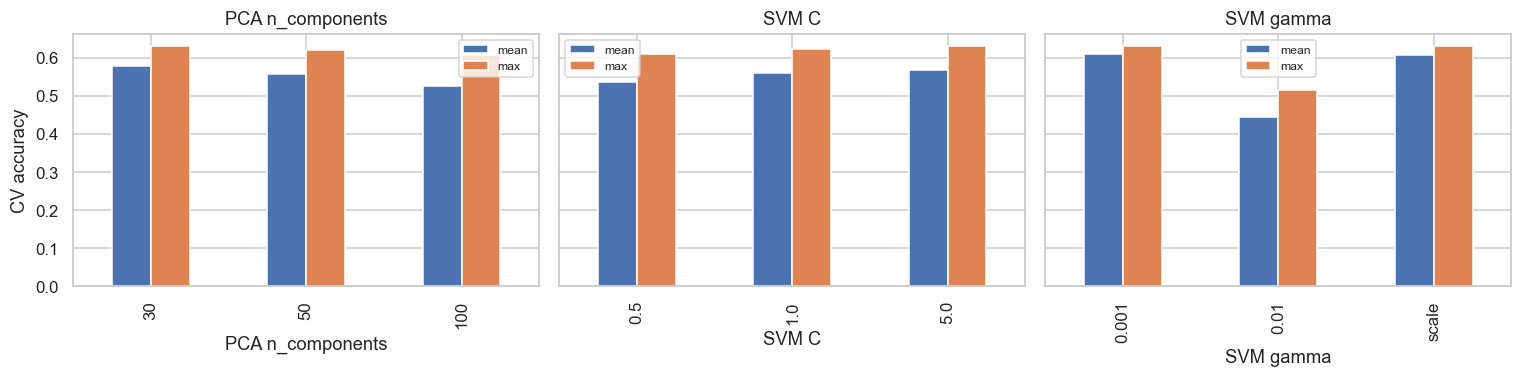

In [15]:
# A2: §3 — Visualise SVM tuning trends.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)

# Aggregate by each hyperparameter individually.
for ax, hp, label in zip(
    axes,
    ["param_pca__n_components", "param_svc__C", "param_svc__gamma"],
    ["PCA n_components", "SVM C", "SVM gamma"],
):
    grouped = svm_results.groupby(hp)["mean_test_score"].agg(["mean", "max"])
    grouped.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("CV accuracy")
    ax.legend(["mean", "max"], fontsize=8)
plt.tight_layout()
plt.show()


### Fully connected neural network

In [16]:
# A2: §3 — MLP grid search (3 hyperparameters: units, dropout, learning rate).
MLP_TUNE_CSV = OUTPUTS_DIR / "mlp_tuning.csv"

mlp_grid = {
    "units":         [64, 128, 256],
    "dropout":       [0.0, 0.3, 0.5],
    "learning_rate": [1e-3, 1e-4],
}

if MLP_TUNE_CSV.exists():
    print(f"Loading cached MLP tuning results from {MLP_TUNE_CSV}")
    mlp_results = pd.read_csv(MLP_TUNE_CSV)
else:
    rows = []
    combos = list(itertools.product(*mlp_grid.values()))
    print(f"Running MLP tuning: {len(combos)} combos, up to 25 epochs each (early stop)")
    for i, (units, dropout, lr) in enumerate(combos, start=1):
        tf.random.set_seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)
        model = make_mlp(units=units, dropout=dropout, learning_rate=lr)
        es = callbacks.EarlyStopping(patience=3, restore_best_weights=True,
                                     monitor="val_accuracy", mode="max")
        t0 = time.time()
        h = model.fit(
            X_tr_norm, y_tr,
            validation_data=(X_val_norm, y_val),
            epochs=25, batch_size=128, verbose=0, callbacks=[es],
        )
        fit_time = time.time() - t0
        val_acc = max(h.history["val_accuracy"])
        rows.append(dict(
            units=units, dropout=dropout, learning_rate=lr,
            val_accuracy=val_acc, fit_time=fit_time,
            epochs_trained=len(h.history["loss"]),
        ))
        print(f"  [{i:>2}/{len(combos)}] units={units:>3}, dropout={dropout:.1f}, "
              f"lr={lr:.0e} -> val_acc={val_acc:.4f} ({fit_time:.1f}s)")
        keras.backend.clear_session()
    mlp_results = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False)
    mlp_results.to_csv(MLP_TUNE_CSV, index=False)
    print(f"Saved -> {MLP_TUNE_CSV}")

display(mlp_results.head(10))
best_mlp = mlp_results.iloc[0]
best_mlp_params = {
    "units":         int(best_mlp["units"]),
    "dropout":       float(best_mlp["dropout"]),
    "learning_rate": float(best_mlp["learning_rate"]),
}
print("Best MLP val accuracy :", round(best_mlp["val_accuracy"], 4))
print("Best MLP hyper-params :", best_mlp_params)


Loading cached MLP tuning results from Outputs/mlp_tuning.csv


,units,dropout,learning_rate,val_accuracy,fit_time,epochs_trained
0,128,0.0,0.0001,0.380625,36.435074,25
1,256,0.0,0.0001,0.362812,33.541407,15
2,64,0.0,0.0001,0.346875,26.280992,19
3,128,0.3,0.0001,0.317500,39.194213,23
4,256,0.5,0.0001,0.317187,50.170353,25
5,128,0.0,0.0010,0.313437,9.095278,6
6,64,0.3,0.0001,0.309375,35.534700,22
7,256,0.3,0.0001,0.305469,23.819105,12
8,64,0.0,0.0010,0.305156,15.592376,11
9,256,0.0,0.0010,0.273594,17.679114,9


Best MLP val accuracy : 0.3806
Best MLP hyper-params : {'units': 128, 'dropout': 0.0, 'learning_rate': 0.0001}


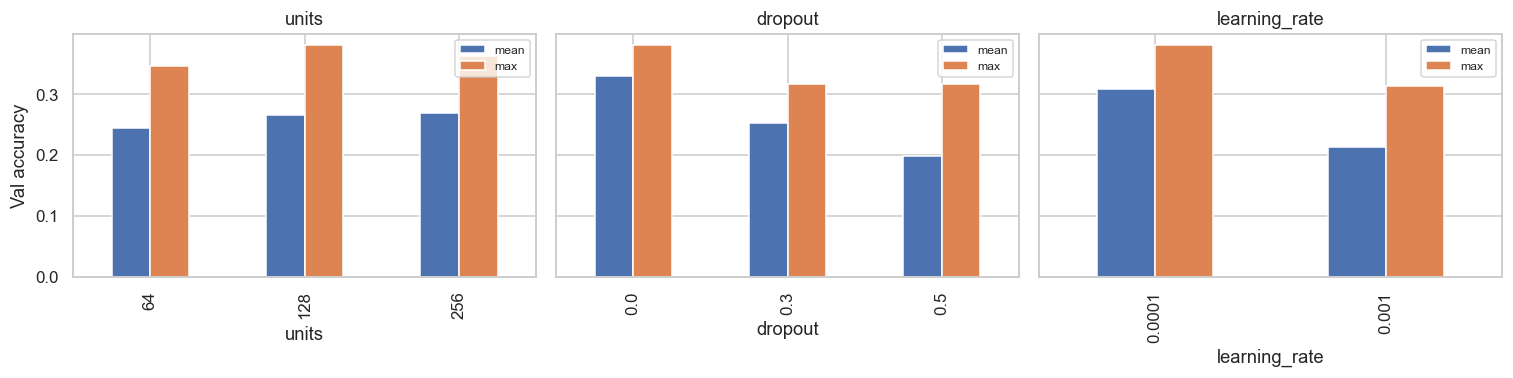

In [17]:
# A2: §3 — Visualise MLP tuning trends.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, hp in zip(axes, ["units", "dropout", "learning_rate"]):
    grouped = mlp_results.groupby(hp)["val_accuracy"].agg(["mean", "max"])
    grouped.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_title(hp)
    ax.set_ylabel("Val accuracy")
    ax.legend(["mean", "max"], fontsize=8)
plt.tight_layout()
plt.show()


### Convolutional neural network

In [18]:
# A2: §3 — CNN grid search (filters, dropout, learning_rate, kernel_size).
CNN_TUNE_CSV = OUTPUTS_DIR / "cnn_tuning.csv"

cnn_grid = {
    "filters":       [16, 32],
    "dropout":       [0.0, 0.3],
    "learning_rate": [1e-3, 1e-4],
    "kernel_size":   [3, 5],
}

if CNN_TUNE_CSV.exists():
    print(f"Loading cached CNN tuning results from {CNN_TUNE_CSV}")
    cnn_results = pd.read_csv(CNN_TUNE_CSV)
else:
    rows = []
    combos = list(itertools.product(*cnn_grid.values()))
    print(f"Running CNN tuning: {len(combos)} combos, up to 25 epochs each (early stop)")
    for i, (filters, dropout, lr, ks) in enumerate(combos, start=1):
        tf.random.set_seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)
        model = make_cnn(filters=filters, dropout=dropout,
                         learning_rate=lr, kernel_size=ks)
        es = callbacks.EarlyStopping(patience=3, restore_best_weights=True,
                                     monitor="val_accuracy", mode="max")
        t0 = time.time()
        h = model.fit(
            X_tr_norm, y_tr,
            validation_data=(X_val_norm, y_val),
            epochs=25, batch_size=128, verbose=0, callbacks=[es],
        )
        fit_time = time.time() - t0
        val_acc = max(h.history["val_accuracy"])
        rows.append(dict(
            filters=filters, dropout=dropout, learning_rate=lr, kernel_size=ks,
            val_accuracy=val_acc, fit_time=fit_time,
            epochs_trained=len(h.history["loss"]),
        ))
        print(f"  [{i:>2}/{len(combos)}] filters={filters:>2}, "
              f"dropout={dropout:.1f}, lr={lr:.0e}, k={ks} -> "
              f"val_acc={val_acc:.4f} ({fit_time:.1f}s)")
        keras.backend.clear_session()
    cnn_results = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False)
    cnn_results.to_csv(CNN_TUNE_CSV, index=False)
    print(f"Saved -> {CNN_TUNE_CSV}")

display(cnn_results.head(10))
best_cnn = cnn_results.iloc[0]
best_cnn_params = {
    "filters":       int(best_cnn["filters"]),
    "dropout":       float(best_cnn["dropout"]),
    "learning_rate": float(best_cnn["learning_rate"]),
    "kernel_size":   int(best_cnn["kernel_size"]),
}
print("Best CNN val accuracy :", round(best_cnn["val_accuracy"], 4))
print("Best CNN hyper-params :", best_cnn_params)


Loading cached CNN tuning results from Outputs/cnn_tuning.csv


,filters,dropout,learning_rate,kernel_size,val_accuracy,fit_time,epochs_trained
0,16,0.3,0.0010,5,0.751719,84.124790,25
1,16,0.3,0.0010,3,0.749687,65.947141,23
2,32,0.3,0.0010,3,0.735313,61.387808,18
3,32,0.3,0.0010,5,0.728437,69.105779,14
4,32,0.0,0.0001,3,0.712031,92.840301,25
5,32,0.3,0.0001,3,0.705312,91.372385,25
6,32,0.0,0.0010,3,0.703438,37.995238,11
7,32,0.3,0.0001,5,0.702031,113.860694,25
8,32,0.0,0.0010,5,0.674688,39.476729,9
9,16,0.0,0.0001,3,0.672656,65.418056,25


Best CNN val accuracy : 0.7517
Best CNN hyper-params : {'filters': 16, 'dropout': 0.3, 'learning_rate': 0.001, 'kernel_size': 5}


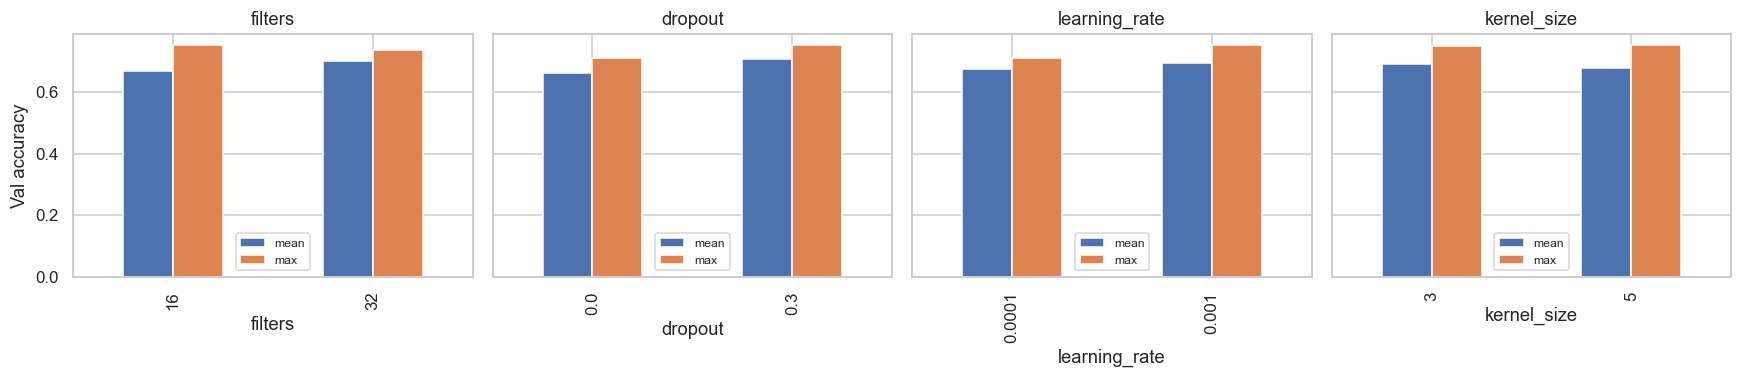

Saved best hyper-parameters -> Outputs/best_hparams.json
{
  "svm": {
    "n_components": 30,
    "C": 5.0,
    "gamma": 0.001
  },
  "mlp": {
    "units": 128,
    "dropout": 0.0,
    "learning_rate": 0.0001
  },
  "cnn": {
    "filters": 16,
    "dropout": 0.3,
    "learning_rate": 0.001,
    "kernel_size": 5
  }
}


In [19]:
# A2: §3 — Visualise CNN tuning trends.
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, hp in zip(axes, ["filters", "dropout", "learning_rate", "kernel_size"]):
    grouped = cnn_results.groupby(hp)["val_accuracy"].agg(["mean", "max"])
    grouped.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
    ax.set_title(hp)
    ax.set_ylabel("Val accuracy")
    ax.legend(["mean", "max"], fontsize=8)
plt.tight_layout()
plt.show()


# Persist the best hyper-parameters for §4 so it can run independently of §3.
best_hparams = {
    "svm": best_svm_params,
    "mlp": best_mlp_params,
    "cnn": best_cnn_params,
}
HPARAMS_PATH = OUTPUTS_DIR / "best_hparams.json"
with open(HPARAMS_PATH, "w") as f:
    json.dump(best_hparams, f, indent=2)
print(f"Saved best hyper-parameters -> {HPARAMS_PATH}")
print(json.dumps(best_hparams, indent=2))


## Hyperparameter Export

In [ ]:
best_hparams = {
    "svm": best_svm_params,
    "mlp": best_mlp_params,
    "cnn": best_cnn_params,
}

HPARAMS_PATH = OUTPUTS_DIR / "best_hparams.json"

with open(HPARAMS_PATH, "w") as f:
    json.dump(best_hparams, f, indent=2)
print(f"Saved best hyper-parameters -> {HPARAMS_PATH}")

print(json.dumps(best_hparams, indent=2))

Saved best hyper-parameters -> Outputs/best_hparams.json
{
  "svm": {
    "n_components": 30,
    "C": 5.0,
    "gamma": 0.001
  },
  "mlp": {
    "units": 128,
    "dropout": 0.0,
    "learning_rate": 0.0001
  },
  "cnn": {
    "filters": 16,
    "dropout": 0.3,
    "learning_rate": 0.001,
    "kernel_size": 5
  }
}


## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

In [ ]:
# A2: §4 — load best hyper-parameters (independent of §3).
# The §3 grid-search cells are slow; markers may skip them. We therefore
# reload the search artefacts from disk and fall back to sensible hard-coded
# values if the file is missing.
HPARAMS_PATH = OUTPUTS_DIR / "best_hparams.json"

DEFAULT_BEST = {
    "svm": {"n_components": 30, "C": 5.0, "gamma": 0.001},
    "mlp": {"units": 128, "dropout": 0.0, "learning_rate": 1e-4},
    "cnn": {"filters": 16, "dropout": 0.3, "learning_rate": 1e-3, "kernel_size": 5},
}

if HPARAMS_PATH.exists():
    with open(HPARAMS_PATH, "r") as f:
        BEST = json.load(f)
    print(f"Loaded best hyper-parameters from {HPARAMS_PATH}")
else:
    BEST = DEFAULT_BEST
    print("Best hyper-parameter file not found - using hard-coded defaults.")

print(json.dumps(BEST, indent=2))
# Container that the final summary table will populate.

final_results = {}


Loaded best hyper-parameters from Outputs/best_hparams.json
{
  "svm": {
    "n_components": 30,
    "C": 5.0,
    "gamma": 0.001
  },
  "mlp": {
    "units": 128,
    "dropout": 0.0,
    "learning_rate": 0.0001
  },
  "cnn": {
    "filters": 16,
    "dropout": 0.3,
    "learning_rate": 0.001,
    "kernel_size": 5
  }
}


### Algorithm of choice from first six weeks of course

SVM trained on full 32,000 samples in 10.7s
Test accuracy : 0.6901
Macro F1      : 0.6826

                                      precision    recall  f1-score   support

                             Adipose       0.87      0.96      0.91       873
                          Background       0.95      0.90      0.92       858
                              Debris       0.48      0.39      0.43       877
                         Lymphocytes       0.92      0.91      0.92       914
                               Mucus       0.67      0.64      0.65       737
                       Smooth Muscle       0.67      0.65      0.66      1072
                 Normal Colon Mucosa       0.54      0.44      0.49       682
            Cancer-associated Stroma       0.51      0.56      0.53       813
Colorectal Adenocarcinoma Epithelium       0.58      0.69      0.63      1174

                            accuracy                           0.69      8000
                           macro avg       0.69  

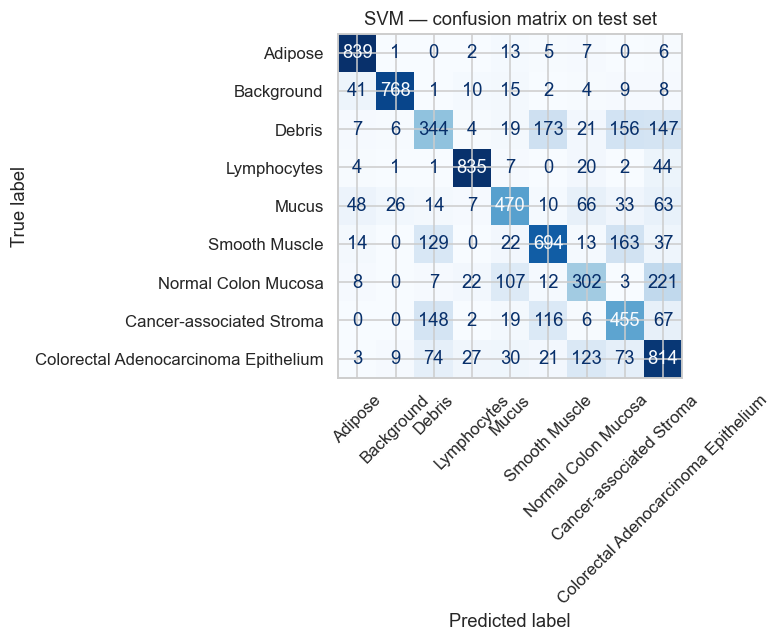

In [22]:
# A2: §4 — Final SVM trained on the entire training set (train + validation).
# We refit on (X_train_flat, y_train) and evaluate on the held-out test set.
svm_final = make_svm(**BEST["svm"])

t0 = time.time()
svm_final.fit(X_train_flat, y_train)
svm_train_time = time.time() - t0

t0 = time.time()
svm_pred = svm_final.predict(X_test_flat)
svm_pred_time = time.time() - t0

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1  = f1_score(y_test, svm_pred, average="macro")
final_results["SVM"] = {
    "test_accuracy":  svm_acc,
    "test_macro_f1":  svm_f1,
    "train_time_s":   svm_train_time,
    "predict_time_s": svm_pred_time,
    "hparams":        BEST["svm"],
}

print(f"SVM trained on full {len(y_train):,} samples in {svm_train_time:.1f}s")
print(f"Test accuracy : {svm_acc:.4f}")
print(f"Macro F1      : {svm_f1:.4f}")
print()
print(classification_report(y_test, svm_pred,
                            target_names=[class_names[i] for i in range(NUM_CLASSES)]))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, svm_pred),
    display_labels=[class_names[i] for i in range(NUM_CLASSES)],
)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45, values_format="d")
ax.set_title("SVM — confusion matrix on test set")
plt.tight_layout()
plt.show()


### Fully connected neural network

Epoch 1/40
225/225 - 1s - 4ms/step - accuracy: 0.2372 - loss: 2.0234 - val_accuracy: 0.2647 - val_loss: 1.9078
Epoch 2/40
225/225 - 0s - 1ms/step - accuracy: 0.2869 - loss: 1.8598 - val_accuracy: 0.3206 - val_loss: 1.8179
Epoch 3/40
225/225 - 0s - 1ms/step - accuracy: 0.3151 - loss: 1.7795 - val_accuracy: 0.3506 - val_loss: 1.7461
Epoch 4/40
225/225 - 0s - 1ms/step - accuracy: 0.3635 - loss: 1.7170 - val_accuracy: 0.4059 - val_loss: 1.6900
Epoch 5/40
225/225 - 0s - 1ms/step - accuracy: 0.3900 - loss: 1.6677 - val_accuracy: 0.4281 - val_loss: 1.6460
Epoch 6/40
225/225 - 0s - 1ms/step - accuracy: 0.4065 - loss: 1.6295 - val_accuracy: 0.4300 - val_loss: 1.6138
Epoch 7/40
225/225 - 0s - 1ms/step - accuracy: 0.4161 - loss: 1.6006 - val_accuracy: 0.4344 - val_loss: 1.5904
Epoch 8/40
225/225 - 0s - 2ms/step - accuracy: 0.4250 - loss: 1.5773 - val_accuracy: 0.4391 - val_loss: 1.5693
Epoch 9/40
225/225 - 0s - 1ms/step - accuracy: 0.4326 - loss: 1.5579 - val_accuracy: 0.4453 - val_loss: 1.5513
E

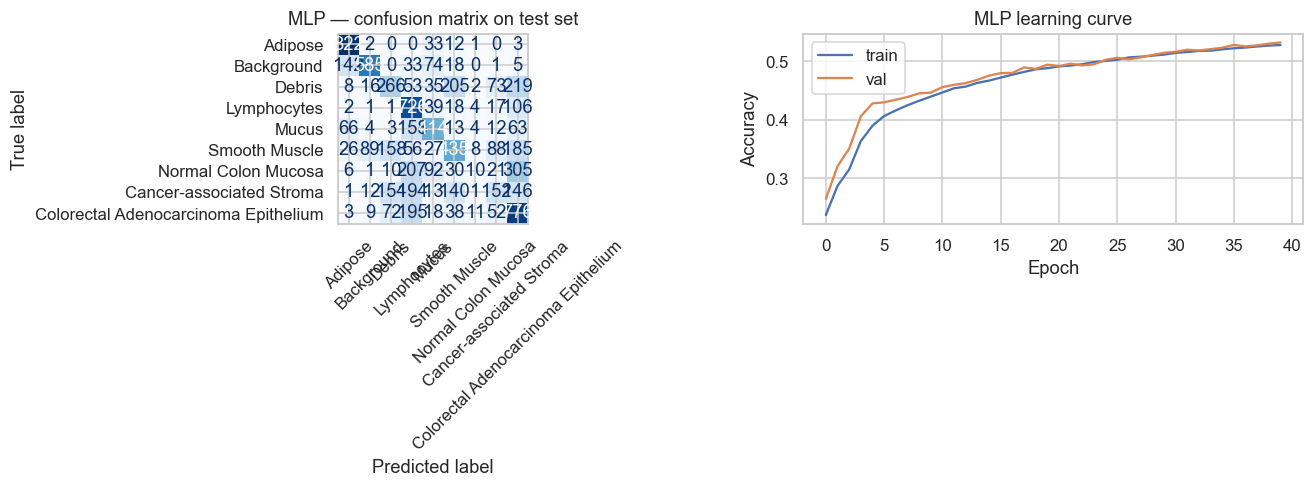

In [23]:
# A2: §4 — Final MLP trained on the entire training set (train + validation).
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

mlp_final = make_mlp(**BEST["mlp"])
es = callbacks.EarlyStopping(patience=4, restore_best_weights=True,
                             monitor="val_accuracy", mode="max")

# Use 10 % of the full training data as a small held-out monitor for early
# stopping; this is independent from y_test (which we never touch during fit).
X_fit, X_es, y_fit, y_es = train_test_split(
    X_train_norm, y_train,
    test_size=0.1, stratify=y_train, random_state=RANDOM_SEED,
)

t0 = time.time()
mlp_hist_final = mlp_final.fit(
    X_fit, y_fit,
    validation_data=(X_es, y_es),
    epochs=40, batch_size=128, verbose=2, callbacks=[es],
)
mlp_train_time = time.time() - t0

t0 = time.time()
mlp_pred = mlp_final.predict(X_test_norm, verbose=0).argmax(axis=1)
mlp_pred_time = time.time() - t0

mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_f1  = f1_score(y_test, mlp_pred, average="macro")
final_results["MLP"] = {
    "test_accuracy":  mlp_acc,
    "test_macro_f1":  mlp_f1,
    "train_time_s":   mlp_train_time,
    "predict_time_s": mlp_pred_time,
    "hparams":        BEST["mlp"],
    "epochs_trained": len(mlp_hist_final.history["loss"]),
}

print(f"MLP trained for {final_results['MLP']['epochs_trained']} epochs in "
      f"{mlp_train_time:.1f}s")
print(f"Test accuracy : {mlp_acc:.4f}")
print(f"Macro F1      : {mlp_f1:.4f}")
print()
print(classification_report(y_test, mlp_pred,
                            target_names=[class_names[i] for i in range(NUM_CLASSES)]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, mlp_pred),
    display_labels=[class_names[i] for i in range(NUM_CLASSES)],
).plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45, values_format="d")
axes[0].set_title("MLP — confusion matrix on test set")

axes[1].plot(mlp_hist_final.history["accuracy"], label="train")
axes[1].plot(mlp_hist_final.history["val_accuracy"], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("MLP learning curve")
axes[1].legend()
plt.tight_layout()
plt.show()


### Convolutional neural network

Epoch 1/40
225/225 - 4s - 16ms/step - accuracy: 0.3294 - loss: 1.7623 - val_accuracy: 0.4925 - val_loss: 1.3719
Epoch 2/40
225/225 - 3s - 12ms/step - accuracy: 0.5086 - loss: 1.3275 - val_accuracy: 0.6128 - val_loss: 1.0892
Epoch 3/40
225/225 - 3s - 12ms/step - accuracy: 0.5664 - loss: 1.1708 - val_accuracy: 0.6625 - val_loss: 0.9599
Epoch 4/40
225/225 - 3s - 12ms/step - accuracy: 0.6060 - loss: 1.0734 - val_accuracy: 0.6766 - val_loss: 0.9252
Epoch 5/40
225/225 - 3s - 13ms/step - accuracy: 0.6415 - loss: 0.9883 - val_accuracy: 0.7075 - val_loss: 0.8390
Epoch 6/40
225/225 - 3s - 12ms/step - accuracy: 0.6538 - loss: 0.9560 - val_accuracy: 0.7013 - val_loss: 0.8347
Epoch 7/40
225/225 - 3s - 12ms/step - accuracy: 0.6599 - loss: 0.9370 - val_accuracy: 0.7097 - val_loss: 0.8309
Epoch 8/40
225/225 - 3s - 14ms/step - accuracy: 0.6743 - loss: 0.8942 - val_accuracy: 0.7181 - val_loss: 0.7904
Epoch 9/40
225/225 - 3s - 13ms/step - accuracy: 0.6892 - loss: 0.8637 - val_accuracy: 0.7272 - val_loss:

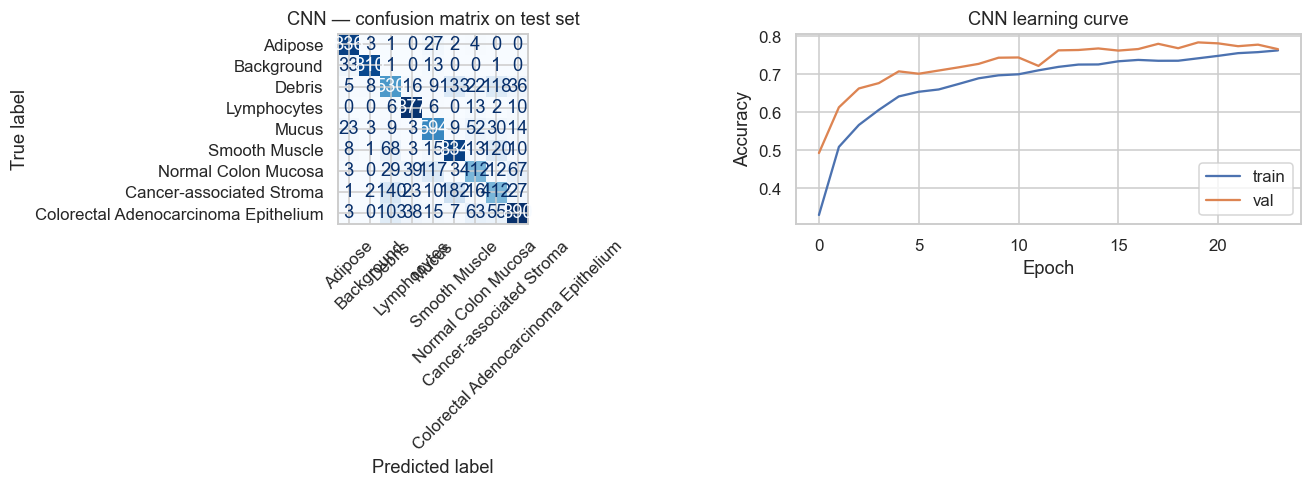

In [24]:
# A2: §4 — Final CNN trained on the entire training set (train + validation).
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

cnn_final = make_cnn(**BEST["cnn"])
es = callbacks.EarlyStopping(patience=4, restore_best_weights=True,
                             monitor="val_accuracy", mode="max")

X_fit, X_es, y_fit, y_es = train_test_split(
    X_train_norm, y_train,
    test_size=0.1, stratify=y_train, random_state=RANDOM_SEED,
)

t0 = time.time()
cnn_hist_final = cnn_final.fit(
    X_fit, y_fit,
    validation_data=(X_es, y_es),
    epochs=40, batch_size=128, verbose=2, callbacks=[es],
)
cnn_train_time = time.time() - t0

t0 = time.time()
cnn_pred = cnn_final.predict(X_test_norm, verbose=0).argmax(axis=1)
cnn_pred_time = time.time() - t0

cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1  = f1_score(y_test, cnn_pred, average="macro")
final_results["CNN"] = {
    "test_accuracy":  cnn_acc,
    "test_macro_f1":  cnn_f1,
    "train_time_s":   cnn_train_time,
    "predict_time_s": cnn_pred_time,
    "hparams":        BEST["cnn"],
    "epochs_trained": len(cnn_hist_final.history["loss"]),
}

print(f"CNN trained for {final_results['CNN']['epochs_trained']} epochs in "
      f"{cnn_train_time:.1f}s")
print(f"Test accuracy : {cnn_acc:.4f}")
print(f"Macro F1      : {cnn_f1:.4f}")
print()
print(classification_report(y_test, cnn_pred,
                            target_names=[class_names[i] for i in range(NUM_CLASSES)]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, cnn_pred),
    display_labels=[class_names[i] for i in range(NUM_CLASSES)],
).plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45, values_format="d")
axes[0].set_title("CNN — confusion matrix on test set")

axes[1].plot(cnn_hist_final.history["accuracy"], label="train")
axes[1].plot(cnn_hist_final.history["val_accuracy"], label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN learning curve")
axes[1].legend()
plt.tight_layout()
plt.show()


### Final-model comparison
The table below consolidates the test-set performance and runtime for each model with its tuned hyper-parameters.

In [25]:
# A2: §4 — Consolidated comparison of the three final models.
summary_rows = []
for name in ["SVM", "MLP", "CNN"]:
    r = final_results[name]
    summary_rows.append({
        "Model":           name,
        "Test accuracy":   round(r["test_accuracy"], 4),
        "Macro F1":        round(r["test_macro_f1"], 4),
        "Train time (s)":  round(r["train_time_s"], 1),
        "Predict time (s)": round(r["predict_time_s"], 1),
        "Hyper-parameters": r["hparams"],
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.to_csv(OUTPUTS_DIR / "final_results.csv", index=False)
with open(OUTPUTS_DIR / "final_results.json", "w") as f:
    json.dump(final_results, f, indent=2, default=str)
print(f"Saved final results to {OUTPUTS_DIR/'final_results.json'}")


,Model,Test accuracy,Macro F1,Train time (s),Predict time (s),Hyper-parameters
0,SVM,0.6901,0.6826,10.7,7.0,"{'n_components': 30, 'C': 5.0, 'gamma': 0.001}"
1,MLP,0.5232,0.4774,13.7,0.2,"{'units': 128, 'dropout': 0.0, 'learning_rate'..."
2,CNN,0.7744,0.7668,70.5,0.4,"{'filters': 16, 'dropout': 0.3, 'learning_rate..."


Saved final results to Outputs/final_results.json


## 5. AI Acknowledgement
We used **Anthropic Claude (Claude Opus 4.7)** through the Claude Code CLI as a coding-and-writing assistant for this assignment.

**How the tool was used:**
* Refactoring Section 1 of this notebook into clearly delimited subsections, fixing a hard-coded sample-count typo, and adding the stratified train/validation split.
* Drafting the model factory functions (`make_svm`, `make_mlp`, `make_cnn`), the grid-search loops for §3 and the test-set evaluation cells in §4.
* Drafting the LaTeX report sections (Introduction, Data, Methods, Results & Discussion, Conclusion).

All AI-suggested code and prose were read, validated, and edited by the group members; numerical results were obtained by executing the code on our own hardware (Apple M3 with `tensorflow-metal`).